# Odległość w latencie vs. odległość w ambiencie, pod różnymi warunkami HydrAMP

**Latent** = przestrzeń `z` (64 wymiary) -- to, co liczyliśmy do tej pory w `latent_jump`.

**Ambient** = przestrzeń wyjścia DEKODERA (rozkład prawdopodobieństwa nad pozycjami/aminokwasami, 25 pozycji x 21-literowy alfabet = 525 wymiarów), potwierdzone w `autoencoder/base.py:31` (`decoder_forward` -- *"Decode latent positions into an ambient representation"*).

**Dlaczego to w ogóle może być inne:** HydrAMP koduje sekwencję do `z` BEZ udziału warunku `c=(c_AMP, c_MIC)` -- enkoder go w ogóle nie widzi. Warunek trafia TYLKO do dekodera (`adapter.py:128-136`, doklejany do wejścia przed dekoderem). Czyli:

- odległość w latencie (`||z_a - z_b||`) dla tej samej pary punktów jest ZAWSZE taka sama, niezależnie od warunku.
- odległość w ambiencie (`||decode(z_a) - decode(z_b)||`) dla TEJ SAMEJ pary MOżE być różna, bo samo dekodowanie zależy od warunku.

Tu sprawdzamy wprost, czy i jak bardzo to się dzieje, dla tych samych par co w `latent_jump` (kandydat vs. sekwencja startowa, kandydat vs. punkt SORBES z którego został wygenerowany), pod trzema warunkami: `AMP_high_MIC=(1,1)`, `AMP_low_MIC=(1,0)`, `non_AMP=(0,0)` -- te same trzy grupy biologiczne, co w analizie `peptide_space`.

## Co to jest `distance_kind` i jak dokładnie liczona jest odległość

`distance_kind` NIE jest inną metryką -- to inny wybór PUNKTU ODNIESIENIA dla tego samego kandydata MUTANG:

- **`candidate_to_origin`**: kandydat vs. sekwencja startowa całej trajektorii (ta sama, z której SORBES zaczął iść).
- **`candidate_to_sorbes_parent`**: kandydat vs. konkretny punkt SORBES, z którego ten kandydat został wygenerowany (czyli o jeden krok wcześniej w trajektorii, nie od samego początku).

Dla każdej z tych dwóch par liczymy DOKŁADNIE ten sam sposób:

1. Bierzemy dwa punkty w LATENCIE (`z_a`, `z_b`) -- kandydata i jego punkt odniesienia. `z_a` jest zawsze świeżo re-enkodowany z tekstu sekwencji (`autoencoder.encode`); `z_b` też, poza `candidate_to_sorbes_parent`, gdzie `z_b` to prawdziwy, oryginalny punkt zapisany przez SORBES podczas chodzenia (nigdy nie re-enkodowany).
2. Dekodujemy KAŻDY z tych dwóch punktów OSOBNO, pod tym samym warunkiem `c`: `a_a = decode(z_a, c)`, `a_b = decode(z_b, c)` -- oba to wektory prawdopodobieństwa 525-wymiarowe (25 pozycji x 21 liter).
3. Liczymy odległość euklidesową MIĘDZY już zdekodowanymi wektorami: `ambient_distance = ||a_a - a_b||`.

Czyli: **najpierw dekodujemy każdy koniec osobno, dopiero POTEM porównujemy** -- nie dekodujemy jakiejś wspólnej "różnicy". To dlatego zmiana `c` może zmienić `ambient_distance`: `decode` zależy od `c`, więc `a_a` i `a_b` osobno przesuwają się (niekoniecznie tak samo) gdy zmienimy `c`, mimo że `z_a` i `z_b` w ogóle się nie zmieniają.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from pep_compass.analysis import ExperimentAnalysis
from pep_compass.analysis.reader import ExperimentReader


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate pyproject.toml')


In [2]:
REPOSITORY_ROOT = find_repository_root(Path.cwd())
RESULTS_PATH = REPOSITORY_ROOT / "experiments/results/locality_experiments_latent_escaping_08_13_26/run"

reader = ExperimentReader(RESULTS_PATH)
selection = reader.select()
analysis = ExperimentAnalysis(selection, plot_theme="paper", use_cache=True)

print(f"{len(selection.runs)} runs selected")


18 runs selected


## Liczenie

1000 kandydatów MUTANG na run (18 runów = do 18 000 par), zdekodowanych pod każdym z 3 warunków -- czyli do 54 000 zdekodowanych punktów na `distance_kind`. Cache'owane, więc ponowne uruchomienie tej komórki po zmianie wykresu niżej nic nie przelicza.

In [3]:
result = analysis.locality.ambient_jump(candidate_sample_size=1000)
display(result.metadata)


{'analysis': 'ambient_jump',
 'autoencoder': {'field_eps': 0.001,
  'jacobian_eps': 0.001,
  'jacobian_mode': 'approx',
  'model_name': 'article_25'},
 'candidate_sample_size': 1000,
 'conditions': {'AMP_high_MIC': [1.0, 1.0],
  'AMP_low_MIC': [1.0, 0.0],
  'non_AMP': [0.0, 0.0]},
 'run_count': 18,
 'unmatched_sorbes_parents': 0}

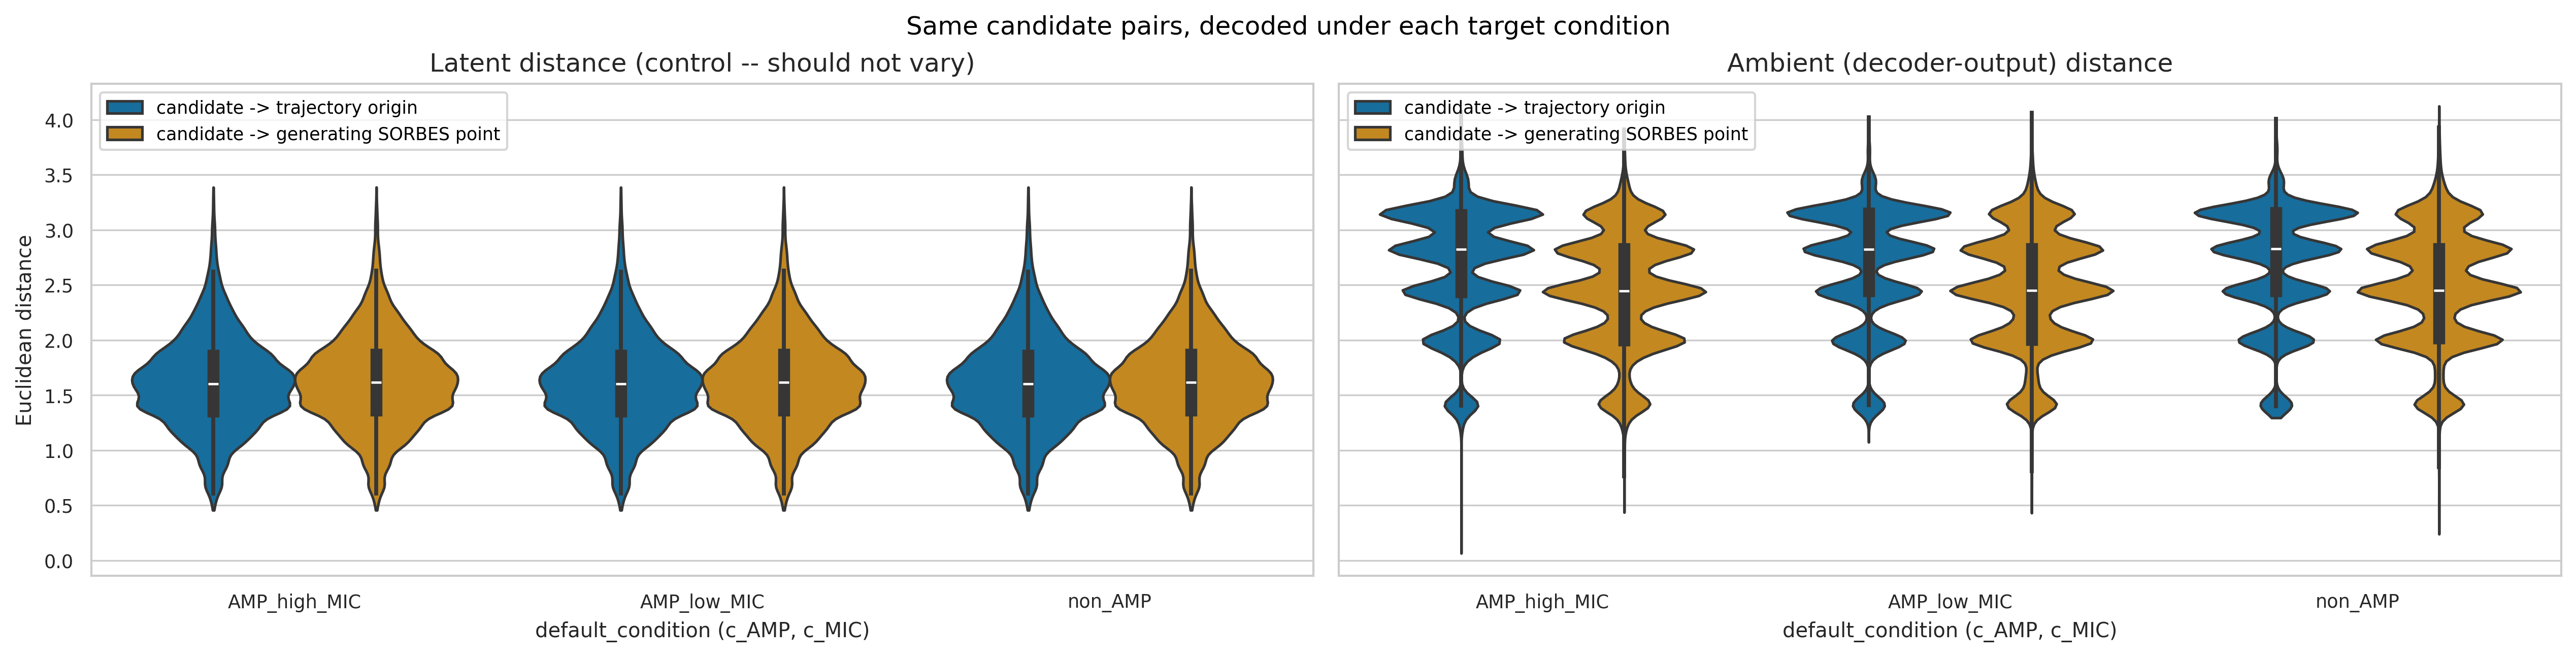

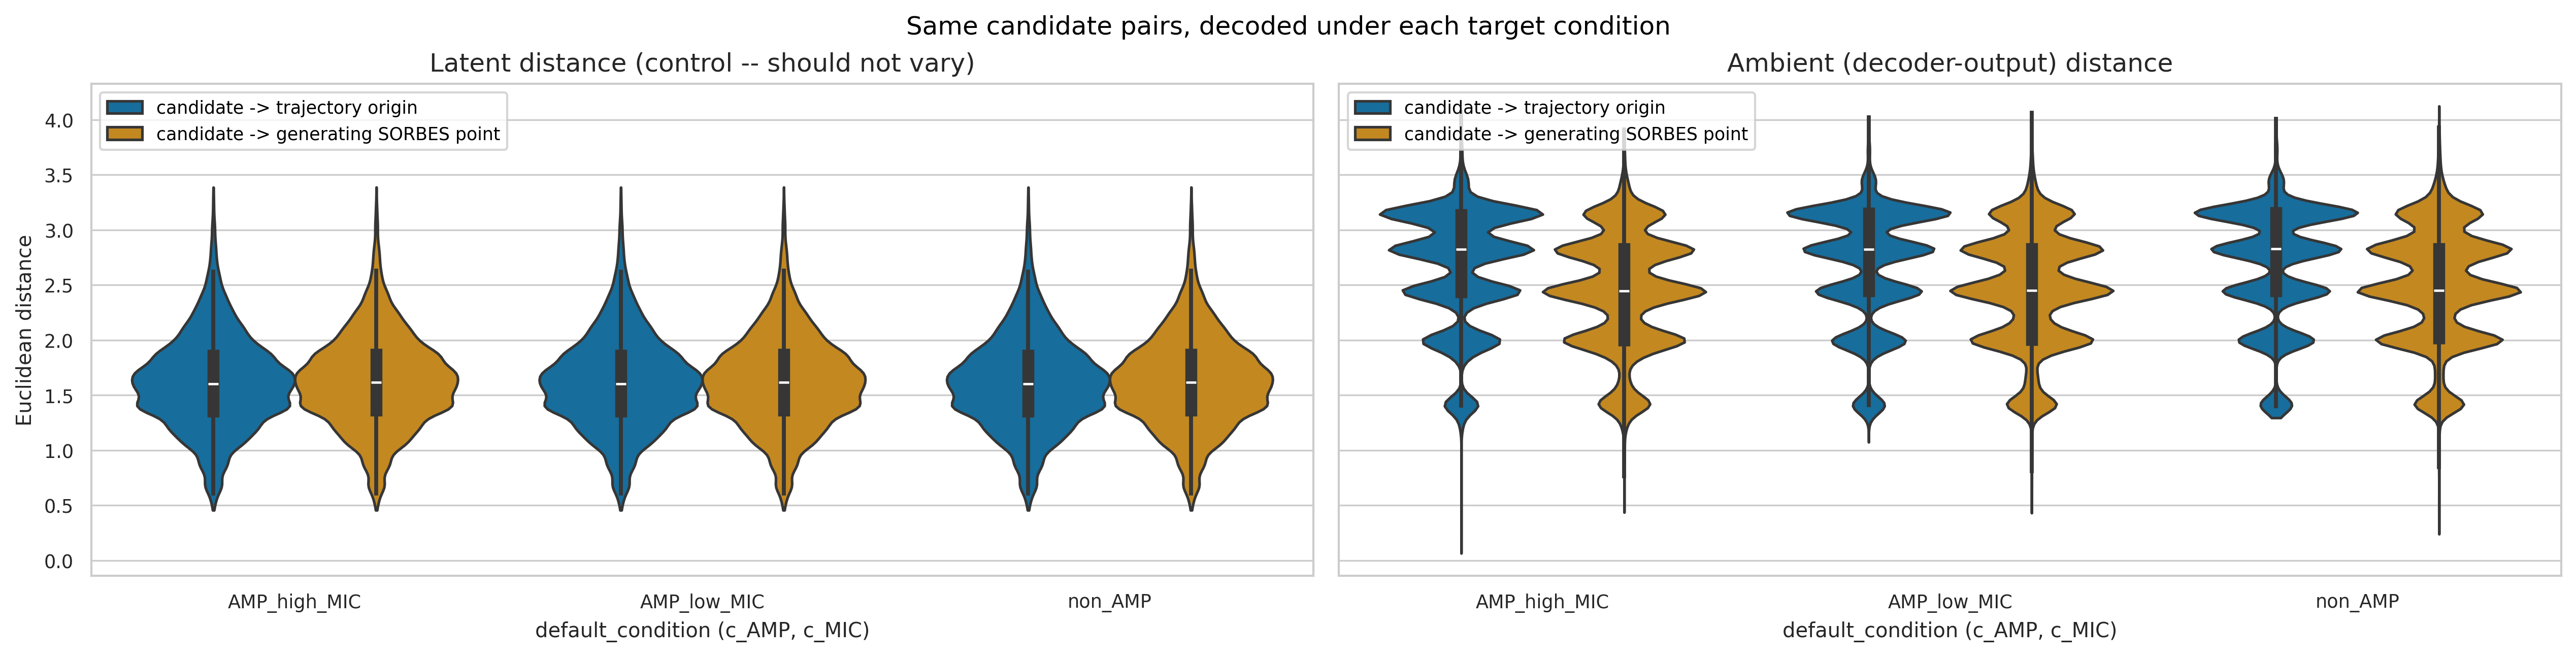

In [4]:
axes = analysis.visualize.locality.ambient_jump(result)
display(axes[0].figure)


## Konkretnie: o ile zmienia się ta odległość między warunkami

Dla każdej pary (ten sam `run_id`, ten sam `distance_kind`, ten sam `candidate_index`) mam trzy liczby `ambient_distance` -- po jednej na warunek. `candidate_index` (nie `sequence`!) to poprawny klucz grupowania -- różni kandydaci mogą mieć identyczny tekst sekwencji (MUTANG potrafi niezależnie wygenerować tę samą sekwencję z różnych rodziców/pozycji), więc grupowanie po samym tekście cichо myliłoby różnych kandydatów jako "tę samą parę". Liczę rozpiętość (max-min) jako procent średniej dla tej pary -- to mówi wprost, o ile % zmienia się odległość tej samej pary w zależności wyłącznie od tego, pod jaki warunek dekodujemy. To samo liczę dla `latent_distance` jako kontrolę -- tam rozpiętość MUSI wyjść dokładnie 0, bo enkodowanie nie zależy od warunku (te same wektory, żadnego przeliczania).

In [5]:
group_cols = ["run_id", "distance_kind", "candidate_index"]

ambient_spread = result.data.groupby(group_cols)["ambient_distance"].agg(["min", "max", "mean"])
ambient_spread["range_pct"] = 100 * (ambient_spread["max"] - ambient_spread["min"]) / ambient_spread["mean"]

latent_spread = result.data.groupby(group_cols)["latent_distance"].agg(["min", "max"])
latent_range = latent_spread["max"] - latent_spread["min"]

print("liczba grup (powinno być: liczba par x 1, każda dokładnie 3 wiersze -- jeden na warunek):")
print(result.data.groupby(group_cols).size().value_counts())
print()
print("latent_distance -- rozpiętość między warunkami (kontrola, oczekujemy dokładnie 0):")
print(latent_range.describe())
print()
print("ambient_distance -- rozpiętość między warunkami, w % średniej dla danej pary:")
print(ambient_spread["range_pct"].describe())
print()
print("10 par z największą rozpiętością (najbardziej wrażliwe na warunek):")
display(
    ambient_spread.sort_values("range_pct", ascending=False)
    .head(10)
    .join(result.data.drop_duplicates(group_cols).set_index(group_cols)["sequence"])
)


liczba grup (powinno być: liczba par x 1, każda dokładnie 3 wiersze -- jeden na warunek):
3    32044
Name: count, dtype: int64

latent_distance -- rozpiętość między warunkami (kontrola, oczekujemy dokładnie 0):
count    32044.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

ambient_distance -- rozpiętość między warunkami, w % średniej dla danej pary:
count    32044.000000
mean         2.898133
std          5.790548
min          0.000000
25%          0.017777
50%          0.301812
75%          3.375625
max        154.696163
Name: range_pct, dtype: float64

10 par z największą rozpiętością (najbardziej wrażliwe na warunek):


,,,min,max,mean,range_pct,sequence
run_id,distance_kind,candidate_index,,,,,
run_00003,candidate_to_origin,137,0.065861,1.349880,0.830026,154.696163,KKYWLIRKWIRLWFET
run_00014,candidate_to_sorbes_parent,299,0.240259,0.938718,0.536920,130.086164,KFRNRVRWKFKETYRI
run_00002,candidate_to_sorbes_parent,101,0.347711,1.372664,0.898803,114.035343,KFRNRHRWKYNLIFRK
run_00014,candidate_to_sorbes_parent,205,0.355340,1.282683,0.827807,112.024049,KFRNRHRWWYLLNFRW
run_00011,candidate_to_sorbes_parent,66,0.554226,1.445195,0.986665,90.301122,RMARNLVRYVPGLKNLKVH
run_00002,candidate_to_sorbes_parent,48,0.921370,2.373398,1.730876,83.889811,KFRNRHRKWFELNFRW
run_00015,candidate_to_sorbes_parent,1601,0.736422,1.895436,1.389330,83.422492,KKYWLIRKWIRLWFEE
run_00009,candidate_to_sorbes_parent,655,0.849043,1.943698,1.359567,80.514991,KKYWLIRQWHRLWFT
run_00017,candidate_to_sorbes_parent,199,0.402113,0.843705,0.588696,75.011771,RMARNLVRYVPGLKNLKVH


## Dlaczego -- mechanizm na konkretnych przykładach

Bierzemy 5 najbardziej wrażliwych par typu `candidate_to_origin` (z tabeli wyżej) i dla każdej:

1. re-enkodujemy kandydata i sekwencję startową do latentu,
2. dekodujemy OBA punkty pod każdym z 3 warunków, ale tym razem BEZ spłaszczania -- zostawiamy kształt `(25 pozycji, 21 liter)`,
3. z każdej pozycji bierzemy zwycięską literę (argmax) ORAZ pewność modelu co do niej (prawdopodobieństwo zwycięzcy -- blisko 100% = model pewny, blisko 1/21 ~ 4.8% = model kompletnie niezdecydowany),
4. patrzymy, czy zdekodowana sekwencja (ta faktycznie odtworzona z rozkładu) w ogóle się zmienia między warunkami, i na której pozycji.

Hipoteza do sprawdzenia: duży skok odległości bierze się z pozycji, gdzie model jest niepewny (prawdopodobieństwo zwycięskiej litery blisko granicy decyzyjnej) -- tam zmiana `c` może przechylić szalę na inną literę, co przesuwa dużo masy prawdopodobieństwa w jednym z 25 21-wymiarowych bloków, nawet jeśli reszta sekwencji się nie rusza.

In [6]:
import torch

from pep_compass.analysis.analysis_types._encoding import encode_sequences
from pep_compass.analysis.analysis_types.locality.latent_jump import (
    _resolve_autoencoder_parameters,
)
from pep_compass.autoencoder.strategies.hydramp.adapter import HydrampAutoencoder
from pep_compass.utils.sequence_utils import translate_generated_peptide

DEVICE = "cpu"
L, V = 25, 21
CONDITIONS = result.metadata["conditions"]

autoencoder_parameters = _resolve_autoencoder_parameters(selection.runs[0].config)
diagnostic_autoencoder = HydrampAutoencoder(device=DEVICE, **autoencoder_parameters)
diagnostic_autoencoder = diagnostic_autoencoder.to(DEVICE).eval()

top_origin_pairs = (
    ambient_spread.reset_index()
    .loc[lambda frame: frame["distance_kind"] == "candidate_to_origin"]
    .sort_values("range_pct", ascending=False)
    .head(5)
)

diagnostic_rows = []
for _, pair in top_origin_pairs.iterrows():
    run_id, candidate_index = pair["run_id"], int(pair["candidate_index"])
    replay = selection.reader.replay(run_id)

    candidate_sequence = result.data.loc[
        (result.data["run_id"] == run_id)
        & (result.data["distance_kind"] == "candidate_to_origin")
        & (result.data["candidate_index"] == candidate_index),
        "sequence",
    ].iloc[0]
    local_enumerations = replay.local_enumerations
    entry_execution_id = int(local_enumerations.iloc[0]["execution_id"])
    origin_sequences, _ = replay.local_enumeration_input(entry_execution_id)
    origin_sequence = origin_sequences[0]

    latents = torch.as_tensor(
        encode_sequences(
            diagnostic_autoencoder, [candidate_sequence, origin_sequence], 2, None
        ),
        dtype=torch.float32,
    )

    print(f"=== run={run_id} candidate_index={candidate_index} range_pct={pair['range_pct']:.1f}% ===")
    print(f"candidate sequence (unchanged across conditions): {candidate_sequence}")
    print(f"origin sequence    (unchanged across conditions): {origin_sequence}")

    per_condition_decoded = {}
    for condition_name, condition_values in CONDITIONS.items():
        diagnostic_autoencoder.default_condition = torch.tensor(
            condition_values, dtype=torch.float32
        )
        with torch.no_grad():
            probs = diagnostic_autoencoder.decoder_forward(latents, flatten=False)  # (2, L, V)
        max_probs, _ = probs.max(dim=-1)  # (2, L)
        candidate_decoded = translate_generated_peptide(probs[0].unsqueeze(0))
        origin_decoded = translate_generated_peptide(probs[1].unsqueeze(0))
        per_condition_decoded[condition_name] = (candidate_decoded, origin_decoded)
        print(
            f"  [{condition_name:12s}] decode(candidate)={candidate_decoded!r:22s} "
            f"decode(origin)={origin_decoded!r:22s} "
            f"min_confidence(candidate)={max_probs[0].min().item():.3f} "
            f"min_confidence(origin)={max_probs[1].min().item():.3f}"
        )
        diagnostic_rows.append(
            {
                "run_id": run_id,
                "candidate_index": candidate_index,
                "range_pct": pair["range_pct"],
                "condition": condition_name,
                "candidate_decoded": candidate_decoded,
                "origin_decoded": origin_decoded,
                "candidate_min_confidence": max_probs[0].min().item(),
                "origin_min_confidence": max_probs[1].min().item(),
            }
        )
    candidate_decodes_differ = len({v[0] for v in per_condition_decoded.values()}) > 1
    origin_decodes_differ = len({v[1] for v in per_condition_decoded.values()}) > 1
    print(
        f"  -> decoded CANDIDATE changes across conditions: {candidate_decodes_differ} | "
        f"decoded ORIGIN changes across conditions: {origin_decodes_differ}"
    )
    print()

diagnostic_table = pd.DataFrame(diagnostic_rows)


=== run=run_00003 candidate_index=137 range_pct=154.7% ===
candidate sequence (unchanged across conditions): KKYWLIRKWIRLWFET
origin sequence    (unchanged across conditions): KKYWLIRKWIRLWFLT


  [AMP_high_MIC] decode(candidate)='KKYWLIRKWIRLWFLT'     decode(origin)='KKYWLIRKWIRLWFLT'     min_confidence(candidate)=0.952 min_confidence(origin)=0.996
  [AMP_low_MIC ] decode(candidate)='KKYWLIRKWIRLWFET'     decode(origin)='KKYWLIRKWIRLWFLT'     min_confidence(candidate)=0.763 min_confidence(origin)=0.992
  [non_AMP     ] decode(candidate)='KKYWLIRKWIRLWFET'     decode(origin)='KKYWLIRKWIRLWFLT'     min_confidence(candidate)=0.960 min_confidence(origin)=0.988
  -> decoded CANDIDATE changes across conditions: True | decoded ORIGIN changes across conditions: False

=== run=run_00000 candidate_index=320 range_pct=38.0% ===
candidate sequence (unchanged across conditions): FNYKWWIRIGRLKL
origin sequence    (unchanged across conditions): FLYKWWIRIGRLKL
  [AMP_high_MIC] decode(candidate)='FKYWWWIRIGRLKL'       decode(origin)='FLYKWWIRIGRLKL'       min_confidence(candidate)=0.869 min_confidence(origin)=1.000
  [AMP_low_MIC ] decode(candidate)='FKYKWWIRIGRLKL'       decode(origin)='FLYK

=== run=run_00000 candidate_index=349 range_pct=38.0% ===
candidate sequence (unchanged across conditions): FNYKWWIRIGRLKL
origin sequence    (unchanged across conditions): FLYKWWIRIGRLKL
  [AMP_high_MIC] decode(candidate)='FKYWWWIRIGRLKL'       decode(origin)='FLYKWWIRIGRLKL'       min_confidence(candidate)=0.869 min_confidence(origin)=1.000
  [AMP_low_MIC ] decode(candidate)='FKYKWWIRIGRLKL'       decode(origin)='FLYKWWIRIGRLKL'       min_confidence(candidate)=0.632 min_confidence(origin)=1.000
  [non_AMP     ] decode(candidate)='FNYKWWIRIGRLKL'       decode(origin)='FLYKWWIRIGRLKL'       min_confidence(candidate)=0.694 min_confidence(origin)=1.000
  -> decoded CANDIDATE changes across conditions: True | decoded ORIGIN changes across conditions: False



=== run=run_00003 candidate_index=283 range_pct=31.9% ===
candidate sequence (unchanged across conditions): KKYWLIRKWIRNWFET
origin sequence    (unchanged across conditions): KKYWLIRKWIRLWFLT
  [AMP_high_MIC] decode(candidate)='KKYWLIRKWIRNWFLT'     decode(origin)='KKYWLIRKWIRLWFLT'     min_confidence(candidate)=0.953 min_confidence(origin)=0.996
  [AMP_low_MIC ] decode(candidate)='KKYWLIRKWIRNWFET'     decode(origin)='KKYWLIRKWIRLWFLT'     min_confidence(candidate)=0.847 min_confidence(origin)=0.992
  [non_AMP     ] decode(candidate)='KKYWLIRKWIRNWFET'     decode(origin)='KKYWLIRKWIRLWFLT'     min_confidence(candidate)=0.978 min_confidence(origin)=0.988
  -> decoded CANDIDATE changes across conditions: True | decoded ORIGIN changes across conditions: False



In [7]:
# Podsumowanie hipotezy: czy niska pewność modelu (blisko granicy decyzyjnej)
# faktycznie towarzyszy przypadkom, gdzie zdekodowana sekwencja się zmienia?
summary = (
    diagnostic_table.groupby(["run_id", "candidate_index"])
    .agg(
        range_pct=("range_pct", "first"),
        candidate_decodes_differ=("candidate_decoded", "nunique"),
        origin_decodes_differ=("origin_decoded", "nunique"),
        min_candidate_confidence=("candidate_min_confidence", "min"),
        min_origin_confidence=("origin_min_confidence", "min"),
    )
    .assign(
        candidate_decodes_differ=lambda d: d["candidate_decodes_differ"] > 1,
        origin_decodes_differ=lambda d: d["origin_decodes_differ"] > 1,
    )
)
display(summary)
print(f"pary z inną zdekodowaną sekwencją kandydata pod różnymi warunkami: {summary['candidate_decodes_differ'].sum()}/{len(summary)}")
print(f"pary z inną zdekodowaną sekwencją originu pod różnymi warunkami: {summary['origin_decodes_differ'].sum()}/{len(summary)}")


range_pct  candidate_decodes_differ  \
run_id    candidate_index                                         
run_00000 320               37.964680                      True   
          346               37.964680                      True   
          349               37.964680                      True   
run_00003 137              154.696163                      True   
          283               31.855153                      True   

                           origin_decodes_differ  min_candidate_confidence  \
run_id    candidate_index                                                    
run_00000 320                              False                  0.631674   
          346                              False                  0.631674   
          349                              False                  0.631674   
run_00003 137                              False                  0.763378   
          283                              False                  0.847114   

                           min_origin_confidence  
run_id    candidate_index                         
run_00000 320                           0.999885  
          346                           0.999885  
          349                           0.999885  
run_00003 137                           0.987770  
          283                           0.987770

pary z inną zdekodowaną sekwencją kandydata pod różnymi warunkami: 5/5
pary z inną zdekodowaną sekwencją originu pod różnymi warunkami: 0/5


**Wniosek:** `latent_distance` wychodzi dokładnie 0.0 dla wszystkich 32 044 par (nie tylko "blisko zera") -- czyli enkoder rzeczywiście w ogóle nie widzi warunku `c`, potwierdzone bez żadnej niejednoznaczności.

`ambient_distance` dla TEJ SAMEJ pary **zmienia się w zależności od warunku, ale nierównomiernie**: mediana rozpiętości to ok. 0.3% średniej -- dla większości par warunek prawie nic nie zmienia. Ale rozkład ma długi ogon: średnia rozpiętość to już ~2.9%, a dla najbardziej wrażliwych par sięga **do 155%** -- czyli dla części kandydatów to, pod jaki warunek dekodujemy, robi bardzo dużą różnicę w tym, jak daleko od siebie lądują w przestrzeni ambientowej (do tego stopnia, że przy jednym warunku odległość może być ponad 2x większa niż przy innym).

**Mechanizm, sprawdzony na 5 najbardziej wrażliwych parach `candidate_to_origin`:** dla wszystkich 5/5 zdekodowana sekwencja KANDYDATA zmienia się między warunkami (np. `KKYWLIRKWIRLWFET` dekoduje się jako `...WFLT` pod `AMP_high_MIC`, ale jako `...WFET` pod `AMP_low_MIC`/`non_AMP` -- jedna litera na pozycji 14). Zdekodowana sekwencja ORIGINU (sekwencji startowej trajektorii) nie zmienia się ANI RAZU (0/5). Różnica jest w pewności modelu: najmniej pewna pozycja u kandydata to 0.63-0.96 prawdopodobieństwa zwycięskiej litery, u originu zawsze >=0.99. Innymi słowy: re-enkodowany kandydat MUTANG ląduje w latencie w miejscu, gdzie dekoder jest niepewny co do 1 pozycji -- na tyle niepewny, że zmiana warunku `c` przechyla szalę na inną literę i przesuwa dużo masy prawdopodobieństwa w tym jednym z 25 bloków. Origin (prawdziwa sekwencja, blisko której leżą też punkty faktycznie zapisane przez SORBES/model podczas treningu) dekoduje się pewnie i stabilnie niezależnie od `c`.

**Co to sugeruje:** wrażliwość na warunek nie jest równomierną właściwością przestrzeni ambientowej -- koncentruje się w konkretnych, mało pewnych pozycjach dekodera, i te mało pewne pozycje częściej trafiają się u re-enkodowanych kandydatów MUTANG niż u sekwencji, które model faktycznie "zna" (origin, punkty SORBES). To spójne z tym, że MUTANG nigdy nie dekoduje swoich sekwencji w prawdziwym pipeline (patrz uwaga metodologiczna niżej) -- ten test re-enkodowuje sekwencję, której dekoder nigdy naprawdę nie wygenerował, więc trafienie w niepewny obszar nie jest zaskakujące.

**Naturalny kolejny krok, jeśli chcesz to pociągnąć dalej:** przegenerować 1-2 z tych "wrażliwych" runów (np. `run_00003`, `run_00000`) z innym `default_condition` i bezpośrednio sprawdzić, czy SORBES/MUTANG faktycznie eksplorują inaczej -- to jedyny test, który rozstrzygnie, czy to ma znaczenie dla prawdziwego zachowania generacji, a nie tylko dla tej syntetycznej metryki post-hoc.

**Uwaga metodologiczna** (znaleziona po drodze, warta zapamiętania): przy grupowaniu kandydatów MUTANG NIE wolno używać samego tekstu `sequence` jako klucza -- różni kandydaci (różni rodzice, różne pozycje w trajektorii) mogą wygenerować identyczny tekst sekwencji. Właściwy klucz to `candidate_index` (pozycja w `final_candidates` tego runu). Pierwsza wersja tej analizy grupowała po `sequence` i pokazywała fałszywie niezerową rozpiętość `latent_distance` (do 0.48) -- to była wina złego grupowania, nie prawdziwa zależność od warunku.